In [1]:
import sys
sys.path.append('.')
import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1
import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator
import params
from params import set_params
import time
from IPython.display import Image
import os 


In [2]:
!which python3 --version
!python --version

/home/dyuser-a/miniconda3/envs/dynapse1/bin/python3
Python 3.8.20


## LOCAL

In [ ]:
# devices = samna.device.get_unopened_devices()

# print(devices)

# try:
#     model, gui = ut.open_dynapse1(gui=False,select_device=True)
# except AttributeError as e:
#     print("\nno board attached") 
#     print(e)
#python -c "import samna; print(samna.device.get_all_devices())"
# [device::DeviceInfo(serial_number=00000007, usb_bus_number=2, usb_device_address=3, logic_version=5, device_type_name=Dynapse1DevKit)]

## SERVER SIDE ZEMO

In [4]:
# open DYNAP-SE1 board to get Dynapse1Model

# The open_dynapse1 utility will initialize communication with the device
# - gui=False: do not open any graphical interface --> the DYNAPSE1 GUI does not work if you connect remotely
# - select_device=True: allow user/device selection if multiple boards are detected --> this is necessary when you are connecting via Zemo, since there is more than 1 board attached

model, _ = ut.open_dynapse1(gui=False, select_device=True)


[0]:  Bus 1 Device 36 Dynapse1DevKit serial_number 00000001
[1]:  Bus 1 Device 55 Dynapse1DevKit serial_number 00000007
[2]:  Bus 1 Device 39 Dynapse1DevKit serial_number 00000000
[3]:  Bus 1 Device 38 Dynapse1DevKit serial_number 00000026
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.
Selected device: 00000007
Sender port: tcp://0.0.0.0:44055
Receiver port: tcp://0.0.0.0:53941
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2


In [16]:
# get Dynapse1 api from the model
api = model.get_dynapse1_api()

In [17]:
# set standard parameters
set_params(model)

In [18]:
config1 = model.get_configuration() 

Remember how to set the parameters. Below you have a reference figure that you can use to understand how setting the "coarse" and "fine" values for the DYNAP-SE1 chip works.

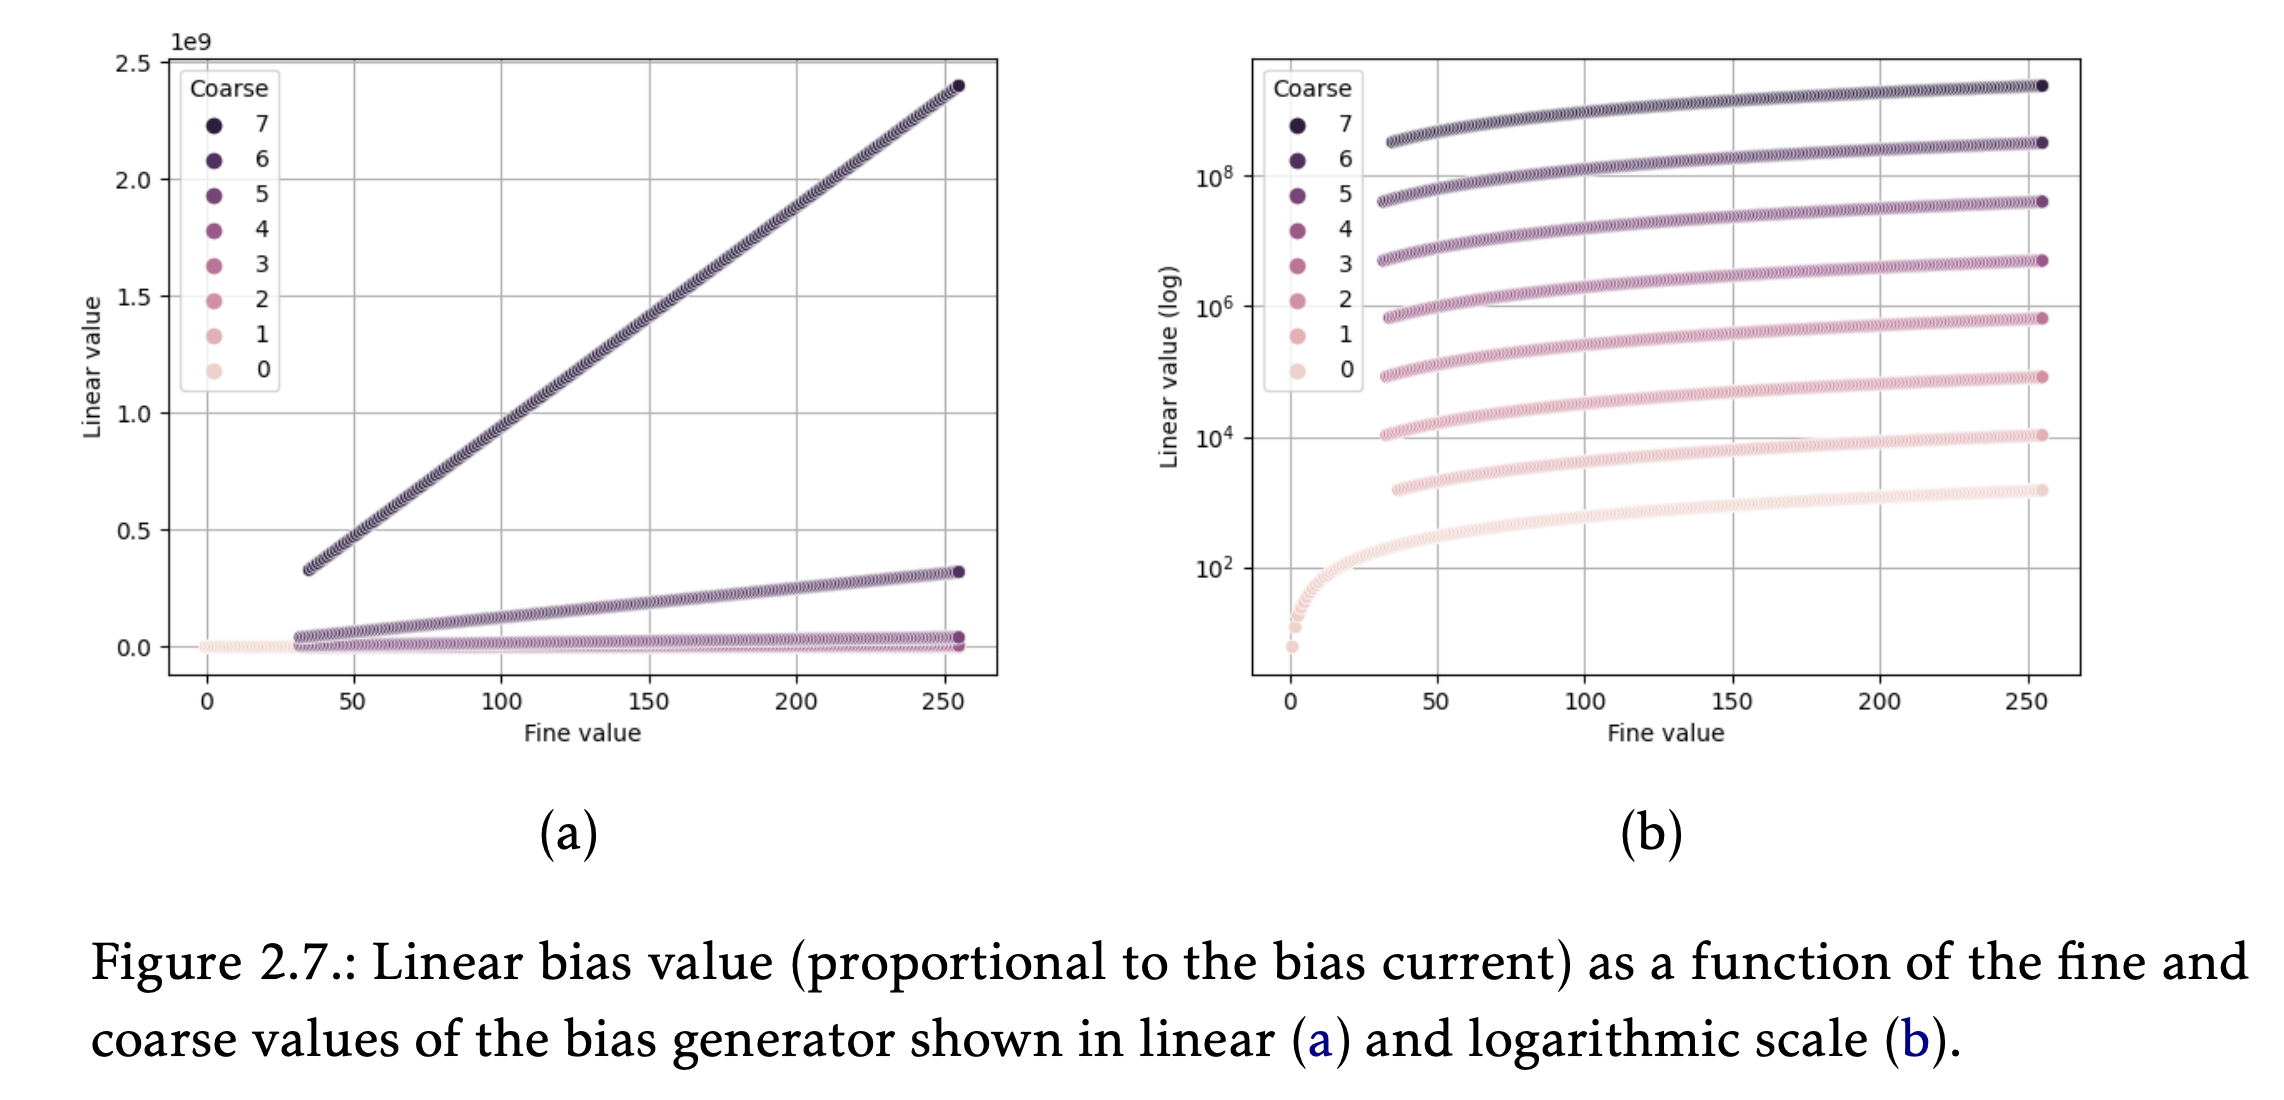

In [19]:
Image("lab5/params_coarse_fine.png")

# New poulation 

In [20]:
# 4 Channels definieren
channels = {
    0: list(range(0, 16)),
    1: list(range(16, 32)),
    2: list(range(32, 48)),
    3: list(range(48, 64))
}


param_group = config1.chips[0].cores[0].parameter_group 

In [40]:
 
import os 


T        = 1.0          # total duration (s)
RATE     = 32           # spikes per second (deterministic, linspace)
N_SPIKES = int(T * RATE)  # = 32 spikes
 
# Per-channel time shifts (ms) — ch0 is aligned to reference
J_SHIFT_PARAM = [0, 10, 25, 50]   # [ch0, ch1, ch2, ch3]
 
N_CH = 4
 
 
#spike generation ─────────────────────────────────────────────────────────────────────────────
# Reference: evenly spaced over [0, T)
t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)
 
# Each channel: same grid, shifted by epsilon_k
# Spikes that go past T are wrapped (modulo T) so count stays constant

##j is the shift parameter for matching $\epsilon$ is 
    #the error rate which the shift can have be to still exicte 

error_e= 0.01
t_ch = []
for j_ms in J_SHIFT_PARAM:
    j_shift  = j_ms * 1e-3 
    t_raw  = t_ref + j_shift 
    t_wrap = t_raw % T          # wrap around
    t_ch.append(np.sort(t_wrap))
# ─────────────────────────────────────────────────────────────────────────────
 
# print(f"{t_ch[0]}\n")
# print(f"{t_ch[1]}\n")
# print(t_ch)
###__________ dicts of channels
## sort list with 2 
dict_list = []

for ch_idx, arr in enumerate(t_ch):
    d = {f"ch_{ch_idx}:{i}": val for i, val in enumerate(arr)}
    dict_list.append(d)

# Separate Variablen:
dict_ch0 = dict_list[0]
dict_ch1 = dict_list[1]
dict_ch2 = dict_list[2]
dict_ch3 = dict_list[3]

print(f"dict_ch0:{dict_ch0}")
dict_ch0={key:val+error_e for key,val in dict_ch0.items()}
print(f"shifted by {error_e}")


print(f"{t_ch[0]}")
print(f"d={dict_ch0}")
###__________ dicts of channels

###_______________ combinded dicts + + list lookup
#zip all values togetherto a list and also the order of the keys 
# Alle Dicts zusammenführen
combined = {}
for d in [dict_ch0, dict_ch1, dict_ch2, dict_ch3]:
    combined.update(d)

# Sortiert nach Value aufsteigend
sorted_items = sorted(combined.items(), key=lambda x: x[1])

# Zwei Listen: values zum senden, keys als lookup
values_list = [val for key, val in sorted_items]   # zum senden
keys_list   = [key for key, val in sorted_items]   # lookup: welcher channel/index

print(f"value_list{values_list}")
print(f"key_list{keys_list}")
###_______________ combinded dicts + list lookup


len(t_ch[0])

dict_ch0:{'ch_0:0': 0.0, 'ch_0:1': 0.03125, 'ch_0:2': 0.0625, 'ch_0:3': 0.09375, 'ch_0:4': 0.125, 'ch_0:5': 0.15625, 'ch_0:6': 0.1875, 'ch_0:7': 0.21875, 'ch_0:8': 0.25, 'ch_0:9': 0.28125, 'ch_0:10': 0.3125, 'ch_0:11': 0.34375, 'ch_0:12': 0.375, 'ch_0:13': 0.40625, 'ch_0:14': 0.4375, 'ch_0:15': 0.46875, 'ch_0:16': 0.5, 'ch_0:17': 0.53125, 'ch_0:18': 0.5625, 'ch_0:19': 0.59375, 'ch_0:20': 0.625, 'ch_0:21': 0.65625, 'ch_0:22': 0.6875, 'ch_0:23': 0.71875, 'ch_0:24': 0.75, 'ch_0:25': 0.78125, 'ch_0:26': 0.8125, 'ch_0:27': 0.84375, 'ch_0:28': 0.875, 'ch_0:29': 0.90625, 'ch_0:30': 0.9375, 'ch_0:31': 0.96875}
shifted by 0.01
[0.      0.03125 0.0625  0.09375 0.125   0.15625 0.1875  0.21875 0.25
 0.28125 0.3125  0.34375 0.375   0.40625 0.4375  0.46875 0.5     0.53125
 0.5625  0.59375 0.625   0.65625 0.6875  0.71875 0.75    0.78125 0.8125
 0.84375 0.875   0.90625 0.9375  0.96875]
d={'ch_0:0': 0.01, 'ch_0:1': 0.04125, 'ch_0:2': 0.0725, 'ch_0:3': 0.10375, 'ch_0:4': 0.135, 'ch_0:5': 0.16625, 'ch_0:

32

In [41]:
#test test this is a test
combined["ch_0:12"]

0.385

=== Reference spike times (s) ===
[0.     0.0312 0.0625 0.0938 0.125  0.1562 0.1875 0.2188 0.25   0.2812
 0.3125 0.3438 0.375  0.4062 0.4375 0.4688 0.5    0.5312 0.5625 0.5938
 0.625  0.6562 0.6875 0.7188 0.75   0.7812 0.8125 0.8438 0.875  0.9062
 0.9375 0.9688]

=== Channel 0  (j_shift = 0 ms) ===
[0.     0.0312 0.0625 0.0938 0.125  0.1562 0.1875 0.2188 0.25   0.2812
 0.3125 0.3438 0.375  0.4062 0.4375 0.4688 0.5    0.5312 0.5625 0.5938
 0.625  0.6562 0.6875 0.7188 0.75   0.7812 0.8125 0.8438 0.875  0.9062
 0.9375 0.9688]

=== Channel 1  (j_shift = 10 ms) ===
[0.01   0.0412 0.0725 0.1038 0.135  0.1662 0.1975 0.2288 0.26   0.2912
 0.3225 0.3538 0.385  0.4162 0.4475 0.4788 0.51   0.5412 0.5725 0.6038
 0.635  0.6662 0.6975 0.7288 0.76   0.7912 0.8225 0.8538 0.885  0.9162
 0.9475 0.9788]

=== Channel 2  (j_shift = 25 ms) ===
[0.025  0.0562 0.0875 0.1188 0.15   0.1812 0.2125 0.2438 0.275  0.3062
 0.3375 0.3688 0.4    0.4312 0.4625 0.4938 0.525  0.5562 0.5875 0.6188
 0.65   0.6812 0.7125 0.

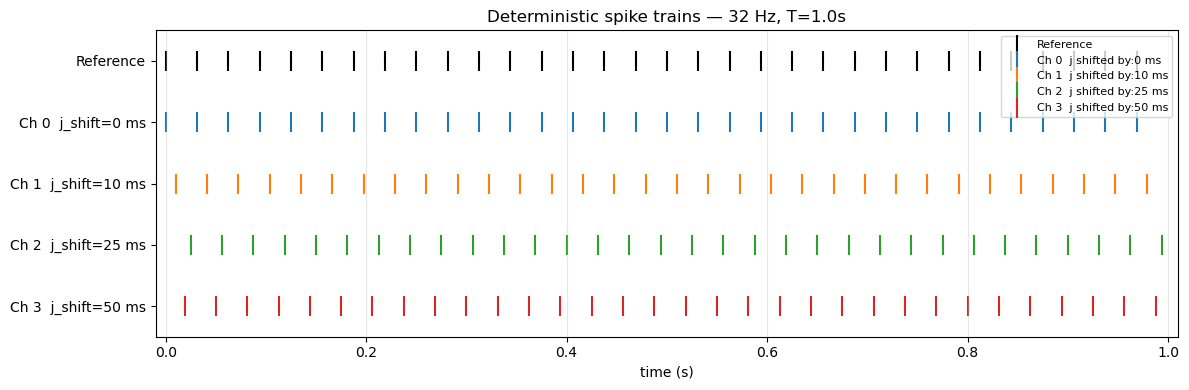


Plot saved to step1_spikes.png


In [42]:
print("=== Reference spike times (s) ===")
print(np.round(t_ref, 4))
 
for ch in range(N_CH):
    print(f"\n=== Channel {ch}  (j_shift = {J_SHIFT_PARAM[ch]} ms) ===")
    print(np.round(t_ch[ch], 4))
 
# ─────────────────────────────────────────────────────────────────────────────
# RASTER PLOT
# ─────────────────────────────────────────────────────────────────────────────
 
fig, ax = plt.subplots(figsize=(12, 4))
 
# y-positions: reference at top (row N_CH), channels below (N_CH-1 down to 0)
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
 
# Reference
y_ref = N_CH
ax.scatter(t_ref, np.full_like(t_ref, y_ref),
           marker='|', s=200, linewidths=1.5, color='black', label='Reference')
 
# Channels
for ch in range(N_CH):
    y = N_CH - 1 - ch
    ax.scatter(t_ch[ch], np.full_like(t_ch[ch], y),
               marker='|', s=200, linewidths=1.5,
               color=COLORS[ch], label=f'Ch {ch}  j shifted by:{J_SHIFT_PARAM[ch]} ms')
 
# Formatting
ax.set_yticks(range(N_CH + 1))
ax.set_yticklabels(
    [f'Ch {N_CH-1-i}  j_shift={J_SHIFT_PARAM[N_CH-1-i]} ms' for i in range(N_CH)] + ['Reference']
)
ax.set_xlabel('time (s)')
ax.set_title(f'Deterministic spike trains — {RATE} Hz, T={T}s')
ax.set_xlim(-0.01, T + 0.01)
ax.set_ylim(-0.5, N_CH + 0.5)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='x', alpha=0.3)
 
plt.tight_layout()
files_found= sys


plot_number_in_dir = len([name for name in os.listdir('./keyspot_plots') if os.path.isfile(os.path.join('./keyspot_plots', name))])
print(plot_number_in_dir)
plt.savefig(f'keyspot_plots/step1_spikes{plot_number_in_dir}.png', dpi=150)



plt.show()
print("\nPlot saved to step1_spikes.png")

In [43]:
!pwd 

/home/dyuser-a/keyspotting/dynap-se1


In [44]:
!ls -a 

.			      jupyterlab-experiments  Readme.md
..			      keyspot_plots	      samna_info.json
board_registry		      lab5		      samna.log
details			      Lab5_P1_p.ipynb	      stdp_algorithms
doc			      live_gui		      stdp.py
dynapse1constants.py	      netgen.py		      stdp_utils.py
dynapse1utils.py	      network_primitives      step1_spikes.png
dynapse-biases-howtosetup.md  parameters	      step3_wta_result.png
example			      params.py		      test
.gitignore		      __pycache__	      tools
.gitlab-ci.yml		      pygetscope	      tutorials
.gitmodules		      pyspcmscope	      wta_4ch_result.png


In [ ]:
"""
STEP 2 — Spike generation → FPGA SpikeGen
==========================================
- 4 channels, 32 spikes/s, deterministic (np.linspace)
- Shifts: J_SHIFT_PARAM = [0, 10, 25, 50] ms
- All spikes merged into one sorted timeline (values_list + keys_list)
- Sent via set_fpga_spike_gen() using the key to derive neuron_id + target_chip
- Spikegen neurons: chip=0, core=1, neuron = ch_idx+1  (1,2,3,4 — avoids slot 0)
"""

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS (from samna / FPGA limits)
# ─────────────────────────────────────────────────────────────────────────────
MAX_ISI      = 2**24        # hardware limit
MAX_FPGA_LEN = 2**16        # max number of events in one preload

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
T             = 1.0               # duration (s)
RATE          = 32                # spikes/s
N_SPIKES      = int(T * RATE)     # = 32
J_SHIFT_PARAM = [0, 10, 25, 50]  # per-channel shift [ms]  → j in your notation
N_CH          = 4
TARGET_CHIP   = 0                 # all on chip 0
ISI_BASE      = 900               # FPGA time unit: 900/90 = 10 µs per tick

# Spikegen neuron IDs on chip=0, core=1
# neuron 0 is reserved → use 1,2,3,4 for ch0,ch1,ch2,ch3
SPIKEGEN_NEURON = {ch: ch + 1 for ch in range(N_CH)}   # {0:1, 1:2, 2:3, 3:4}

# ─────────────────────────────────────────────────────────────────────────────
# SPIKE GENERATION
# ─────────────────────────────────────────────────────────────────────────────
t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)

t_ch = []
for j_ms in J_SHIFT_PARAM:
    j_shift = j_ms * 1e-3
    t_raw   = t_ref + j_shift
    t_wrap  = t_raw % T          # wrap — keeps N_SPIKES constant per channel
    t_ch.append(np.sort(t_wrap))

# ─────────────────────────────────────────────────────────────────────────────
# BUILD DICTS + COMBINED SORTED TIMELINE  (your existing logic, unchanged)
# ─────────────────────────────────────────────────────────────────────────────
#done  above 



# ─────────────────────────────────────────────────────────────────────────────
# DECODE KEYS → neuron_id + target_chip per event
# ─────────────────────────────────────────────────────────────────────────────
# key format: "ch_X:spike_idx"  →  channel X  →  neuron SPIKEGEN_NEURON[X]
def key_to_neuron(key):
    ch_idx = int(key.split(":")[0].split("_")[1])
    return SPIKEGEN_NEURON[ch_idx]

indices      = [key_to_neuron(k) for k in keys_list]   # neuron_id per event
target_chips = [TARGET_CHIP] * len(values_list)         # all chip 0

# ─────────────────────────────────────────────────────────────────────────────
# SET_FPGA_SPIKE_GEN  (from utils, verbatim — only call it here)
# ─────────────────────────────────────────────────────────────────────────────
def set_fpga_spike_gen(fpga_spike_gen, spike_times, indices, target_chips,
                       isi_base, repeat_mode=False):
    """
    Author: Nicoletta Risi. Adapted by Jingyue Zhao.
    Converts spike times (s) → FPGA ISI events and preloads the spike generator.
    """
    assert all(np.sort(spike_times) == spike_times), \
        'Spike times must be sorted!'
    assert len(indices) == len(spike_times) == len(target_chips), \
        'spike_times, indices and target_chips must have the same length'

    unit_fpga               = isi_base / 90                          # µs per tick
    spike_times_us          = np.array(spike_times) * 1e6            # s → µs
    spike_times_unit_fpga   = (spike_times_us / unit_fpga).astype(int)
    fpga_isi                = np.array([0] + list(np.diff(spike_times_unit_fpga)),
                                       dtype=int)
    fpga_nrn_ids            = np.array(indices)
    fpga_target_chips       = np.array(target_chips)

    fpga_events = []
    for idx_isi, isi in enumerate(fpga_isi):
        ev              = dyn1.FpgaSpikeEvent()
        ev.core_mask    = 15          # broadcast to all 4 cores on the chip
        ev.target_chip  = int(fpga_target_chips[idx_isi])
        ev.neuron_id    = int(fpga_nrn_ids[idx_isi])
        ev.isi          = int(isi)
        fpga_events.append(ev)

    assert all(np.asarray(fpga_isi) < MAX_ISI), \
        'ISI too large for the specified isi_base! Lower RATE or increase ISI_BASE.'
    assert len(fpga_isi) < MAX_FPGA_LEN, \
        'Stimulus too long! Reduce N_SPIKES or T.'

    fpga_spike_gen.set_variable_isi_mode(True)
    fpga_spike_gen.preload_stimulus(fpga_events)
    fpga_spike_gen.set_isi_multiplier(isi_base)
    fpga_spike_gen.set_repeat_mode(repeat_mode)
    print(f"  → {len(fpga_events)} events preloaded "
          f"(isi_base={isi_base}, unit={unit_fpga} µs/tick, "
          f"repeat={repeat_mode})")


# ─────────────────────────────────────────────────────────────────────────────
# SEND TO HARDWARE
# ─────────────────────────────────────────────────────────────────────────────
def send_spikes(model, repeat=True):
    """Preload all 4 channel spike trains onto the FPGA spike generator."""
    fpga_spike_gen = model.get_fpga_spike_gen()

    print(f"\nSending {len(values_list)} events to FPGA spike gen...")
    print(f"  Channels   : {N_CH}")
    print(f"  Spikes/ch  : {N_SPIKES}")
    print(f"  Shifts (ms): {J_SHIFT_PARAM}")
    print(f"  Neuron IDs : {list(SPIKEGEN_NEURON.values())}  (chip={TARGET_CHIP}, core=1)")

    set_fpga_spike_gen(
        fpga_spike_gen  = fpga_spike_gen,
        spike_times     = values_list,     # sorted merged timeline (s)
        indices         = indices,         # neuron_id per event
        target_chips    = target_chips,    # all chip 0
        isi_base        = ISI_BASE,
        repeat_mode     = repeat,
    )
    print("Done. Call fpga_spike_gen.start() to begin.")
    return fpga_spike_gen


# ─────────────────────────────────────────────────────────────────────────────
# QUICK SANITY PRINT (no hardware needed)
# ─────────────────────────────────────────────────────────────────────────────
print("=== Merged sorted spike timeline (first 20 events) ===")
for k, v in sorted_items[:20]:
    ch = int(k.split(":")[0].split("_")[1])
    print(f"  t={v:.4f}s   key={k:12s}   neuron_id={SPIKEGEN_NEURON[ch]}")

print(f"\nTotal events : {len(values_list)}")
print(f"Expected     : {N_CH * N_SPIKES}")

# ─────────────────────────────────────────────────────────────────────────────
# USAGE  (run this after connecting to the board)
# ─────────────────────────────────────────────────────────────────────────────
# model, _ = ut.open_dynapse1(gui=False, select_device=True)
# fpga_spike_gen = send_spikes(model, repeat=True)
# fpga_spike_gen.start()
# ... record events ...
# fpga_spike_gen.stop()

=== Merged sorted spike timeline (first 20 events) ===
  t=0.0100s   key=ch_0:0         neuron_id=1
  t=0.0100s   key=ch_1:0         neuron_id=2
  t=0.0188s   key=ch_3:0         neuron_id=4
  t=0.0250s   key=ch_2:0         neuron_id=3
  t=0.0413s   key=ch_0:1         neuron_id=1
  t=0.0413s   key=ch_1:1         neuron_id=2
  t=0.0500s   key=ch_3:1         neuron_id=4
  t=0.0563s   key=ch_2:1         neuron_id=3
  t=0.0725s   key=ch_0:2         neuron_id=1
  t=0.0725s   key=ch_1:2         neuron_id=2
  t=0.0813s   key=ch_3:2         neuron_id=4
  t=0.0875s   key=ch_2:2         neuron_id=3
  t=0.1037s   key=ch_0:3         neuron_id=1
  t=0.1037s   key=ch_1:3         neuron_id=2
  t=0.1125s   key=ch_3:3         neuron_id=4
  t=0.1187s   key=ch_2:3         neuron_id=3
  t=0.1350s   key=ch_0:4         neuron_id=1
  t=0.1350s   key=ch_1:4         neuron_id=2
  t=0.1437s   key=ch_3:4         neuron_id=4
  t=0.1500s   key=ch_2:4         neuron_id=3

Total events : 128
Expected     : 128


Network applied.
New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 1
1443 events recorded.


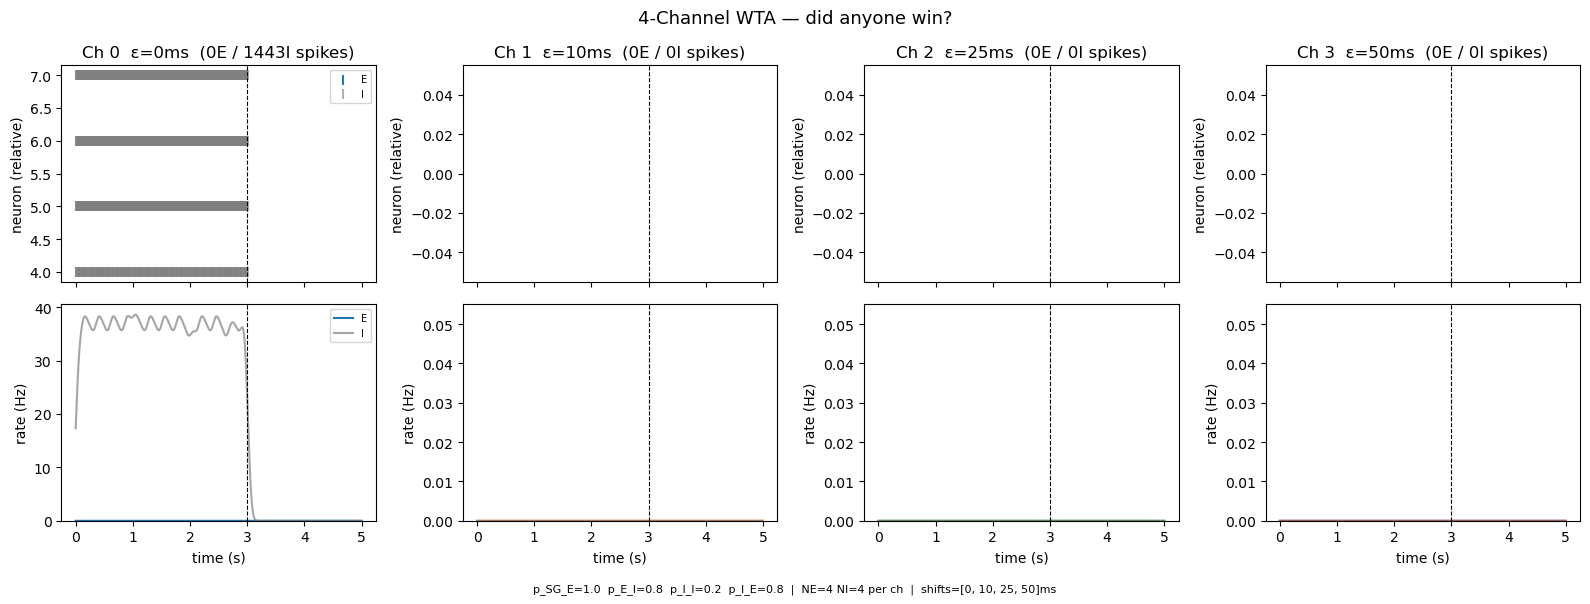

Saved: step3_wta_result.png


In [ ]:
"""
STEP 3 — Network + Run + Plot
==============================
Layout (CHIP 0):
  Core 1 : Spikegens  neuron 1,2,3,4  → ch0,ch1,ch2,ch3
  Core 0 : E pop      neurons  1–16   (NE=16 per channel, stacked)
           I pop      neurons 17–32

WTA wiring:
  spikegen_ch  --AMPA-->  E_ch          (drive)
  E_ch         --AMPA-->  I_ch          (excite local inhibition)
  I_ch         --GABA_B-> E_other_chs   (suppress competition)
  I_ch         --GABA_A-> I_ch          (local stabilisation, optional)
"""
# ─────────────────────────────────────────────────────────────────────────────
# 1. SPIKE GENERATION  (same as step2)
# ─────────────────────────────────────────────────────────────────────────────
MAX_ISI      = 2**24
MAX_FPGA_LEN = 2**16

T             = 1.0
RATE          = 32
N_SPIKES      = int(T * RATE)
J_SHIFT_PARAM = [0, 10, 25, 50]   # ms
N_CH          = 4
TARGET_CHIP   = 0
ISI_BASE      = 900

t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)
t_ch  = []
for j_ms in J_SHIFT_PARAM:
    t_raw  = t_ref + j_ms * 1e-3
    t_ch.append(np.sort(t_raw % T))

# merge + sort
dict_list = []
for ch_idx, arr in enumerate(t_ch):
    dict_list.append({f"ch_{ch_idx}:{i}": val for i, val in enumerate(arr)})

combined     = {}
for d in dict_list: combined.update(d)
sorted_items = sorted(combined.items(), key=lambda x: x[1])
values_list  = [val for key, val in sorted_items]
keys_list    = [key for key, val in sorted_items]

# neuron id per event: ch0→1, ch1→2, ch2→3, ch3→4
SPIKEGEN_NRN = {ch: ch + 1 for ch in range(N_CH)}   # on core 1
def key_to_nrn(key): return SPIKEGEN_NRN[int(key.split(":")[0].split("_")[1])]

indices      = [key_to_nrn(k) for k in keys_list]
target_chips = [TARGET_CHIP] * len(values_list)

# ─────────────────────────────────────────────────────────────────────────────
# 2. NEURON OBJECTS
# ─────────────────────────────────────────────────────────────────────────────
NE_CH = 4    # E neurons per channel
NI_CH = 4    # I neurons per channel
# Slot layout inside core 0:
#   ch0: E → 1..4,    I → 17..20
#   ch1: E → 5..8,    I → 21..24
#   ch2: E → 9..12,   I → 25..28
#   ch3: E → 13..16,  I → 29..32
# (neuron 0 is always skipped — reserved)

spikegens  = [Neuron(0, 1, ch + 1, True) for ch in range(N_CH)]

neurons_E  = []   # list of lists: neurons_E[ch] = [Neuron, ...]
neurons_I  = []
for ch in range(N_CH):
    e_start = 1  + ch * NE_CH          #  1, 5, 9, 13
    i_start = 17 + ch * NI_CH          # 17,21,25,29
    neurons_E.append([Neuron(0, 0, e_start + i) for i in range(NE_CH)])
    neurons_I.append([Neuron(0, 0, i_start + i) for i in range(NI_CH)])

# IDs for monitoring
E_ids = [(0, 0, 1  + ch * NE_CH + i) for ch in range(N_CH) for i in range(NE_CH)]
I_ids = [(0, 0, 17 + ch * NI_CH + i) for ch in range(N_CH) for i in range(NI_CH)]

# ─────────────────────────────────────────────────────────────────────────────
# 3. CONNECTION PROBABILITIES
# ─────────────────────────────────────────────────────────────────────────────
p_SG_E  = 1.0    # spikegen → E  (AMPA)
p_E_I   = 0.8    # E → I within channel  (AMPA)
p_I_I   = 0.2    # I → I within channel  (GABA_A)
p_I_E   = 0.8    # I → E of OTHER channels  (GABA_B)  ← WTA

# ─────────────────────────────────────────────────────────────────────────────
# 4. BUILD NETWORK
# ─────────────────────────────────────────────────────────────────────────────
net_gen = NetworkGenerator()
net_gen.clear_network()

for ch in range(N_CH):
    E = neurons_E[ch]
    I = neurons_I[ch]
    sg = spikegens[ch]

    # spikegen → E  (AMPA)
    for e in E:
        if p_SG_E > np.random.uniform():
            net_gen.add_connection(sg, e, dyn1.Dynapse1SynType.AMPA)

    # E → I within channel  (AMPA)
    for e in E:
        for i_nrn in I:
            if p_E_I > np.random.uniform():
                net_gen.add_connection(e, i_nrn, dyn1.Dynapse1SynType.AMPA)

    # I → I within channel  (GABA_A, stabilise)
    for idx_a, ia in enumerate(I):
        for idx_b, ib in enumerate(I):
            if idx_a != idx_b and p_I_I > np.random.uniform():
                net_gen.add_connection(ia, ib, dyn1.Dynapse1SynType.GABA_A)

    # I → E of ALL OTHER channels  (GABA_B — this is the WTA)
    for other_ch in range(N_CH):
        if other_ch == ch:
            continue
        for i_nrn in I:
            for e in neurons_E[other_ch]:
                if p_I_E > np.random.uniform():
                    net_gen.add_connection(i_nrn, e, dyn1.Dynapse1SynType.GABA_B)

new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)
print("Network applied.")

# ─────────────────────────────────────────────────────────────────────────────
# 5. SET FPGA SPIKE GEN
from dynapse1utils import set_fpga_spike_gen ###get the sendign describtion from the utils file 

fpga_spike_gen = model.get_fpga_spike_gen()
set_fpga_spike_gen(fpga_spike_gen, values_list, indices, target_chips,
                   ISI_BASE, repeat_mode=True)

# ─────────────────────────────────────────────────────────────────────────────
# 6. RUN
# ─────────────────────────────────────────────────────────────────────────────
set_params(model, param_group=param_group)

D_stim = 3.0   # s — run for 3 full seconds (= 3 pattern repeats)
D_post = 2.0   # s — record after stimulus off

monitored = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored)

graph.start()
filter_node.set_neurons(monitored)
sink_node.get_events()    # flush
api.reset_timestamp()


fpga_spike_gen.start()
time.sleep(D_stim)
fpga_spike_gen.stop()
time.sleep(D_post)
graph.stop()

events = sink_node.get_events()
print(f"{len(events)} events recorded.")

# ─────────────────────────────────────────────────────────────────────────────
# 7. PARSE EVENTS
# ─────────────────────────────────────────────────────────────────────────────
spike_t    = np.array([e.timestamp * 1e-6 for e in events])
spike_core = np.array([e.core_id          for e in events])
spike_nrn  = np.array([e.neuron_id        for e in events])

D = D_stim + D_post

# Per-channel spike times for E and I
def ch_spikes(ch, pop):
    if pop == 'E':
        lo, hi = 1 + ch * NE_CH, 1 + ch * NE_CH + NE_CH
    else:
        lo, hi = 17 + ch * NI_CH, 17 + ch * NI_CH + NI_CH
    mask = (spike_core == 0) & (spike_nrn >= lo) & (spike_nrn < hi)
    return spike_t[mask], spike_nrn[mask]

# ─────────────────────────────────────────────────────────────────────────────
# 8. FIRING RATE  (Gaussian kernel)
# ─────────────────────────────────────────────────────────────────────────────
fs    = 500
bins  = int(D * fs)
t_ax  = np.arange(bins) / fs
sigma = 0.05
x_k   = np.arange(int(-0.5 * fs), int(0.5 * fs)) / fs
gauss = np.exp(-x_k**2 / (2 * sigma**2)); gauss /= gauss.sum()

def pop_rate(times, n):
    b   = np.zeros(bins)
    idx = (times * fs).astype(int)
    idx = idx[(idx >= 0) & (idx < bins)]
    b[idx] = 1
    return np.convolve(b, gauss, 'same') * fs / n

E_rate = [pop_rate(ch_spikes(ch, 'E')[0], NE_CH) for ch in range(N_CH)]
I_rate = [pop_rate(ch_spikes(ch, 'I')[0], NI_CH) for ch in range(N_CH)]

# ─────────────────────────────────────────────────────────────────────────────
# 9. PLOT
# ─────────────────────────────────────────────────────────────────────────────
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
fig, axes = plt.subplots(2, N_CH, figsize=(16, 6), sharex=True)
fig.suptitle("4-Channel WTA — did anyone win?", fontsize=13)

for ch in range(N_CH):
    t_E, n_E = ch_spikes(ch, 'E')
    t_I, n_I = ch_spikes(ch, 'I')

    # raster
    ax = axes[0, ch]
    ax.scatter(t_E, n_E - (1 + ch * NE_CH),        color=COLORS[ch], marker='|', s=60, label='E')
    ax.scatter(t_I, n_I - (17 + ch * NI_CH) + NE_CH, color='gray',    marker='|', s=60, alpha=0.6, label='I')
    ax.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax.set_title(f"Ch {ch}  ε={J_SHIFT_PARAM[ch]}ms  "
                 f"({len(t_E)}E / {len(t_I)}I spikes)")
    ax.set_ylabel("neuron (relative)")
    if ch == 0: ax.legend(fontsize=7)

    # rate
    ax = axes[1, ch]
    ax.plot(t_ax, E_rate[ch], color=COLORS[ch], label='E')
    ax.plot(t_ax, I_rate[ch], color='gray',     label='I', alpha=0.7)
    ax.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax.set_xlabel("time (s)")
    ax.set_ylabel("rate (Hz)")
    ax.set_ylim(bottom=0)
    if ch == 0: ax.legend(fontsize=7)

plt.figtext(0.5, 0.01,
    f"p_SG_E={p_SG_E}  p_E_I={p_E_I}  p_I_I={p_I_I}  p_I_E={p_I_E}  |  "
    f"NE={NE_CH} NI={NI_CH} per ch  |  shifts={J_SHIFT_PARAM}ms",
    ha='center', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("keyspot_plots\step3_wta_result.png", dpi=150)
plt.show()
print("Saved: step3_wta_result.png")

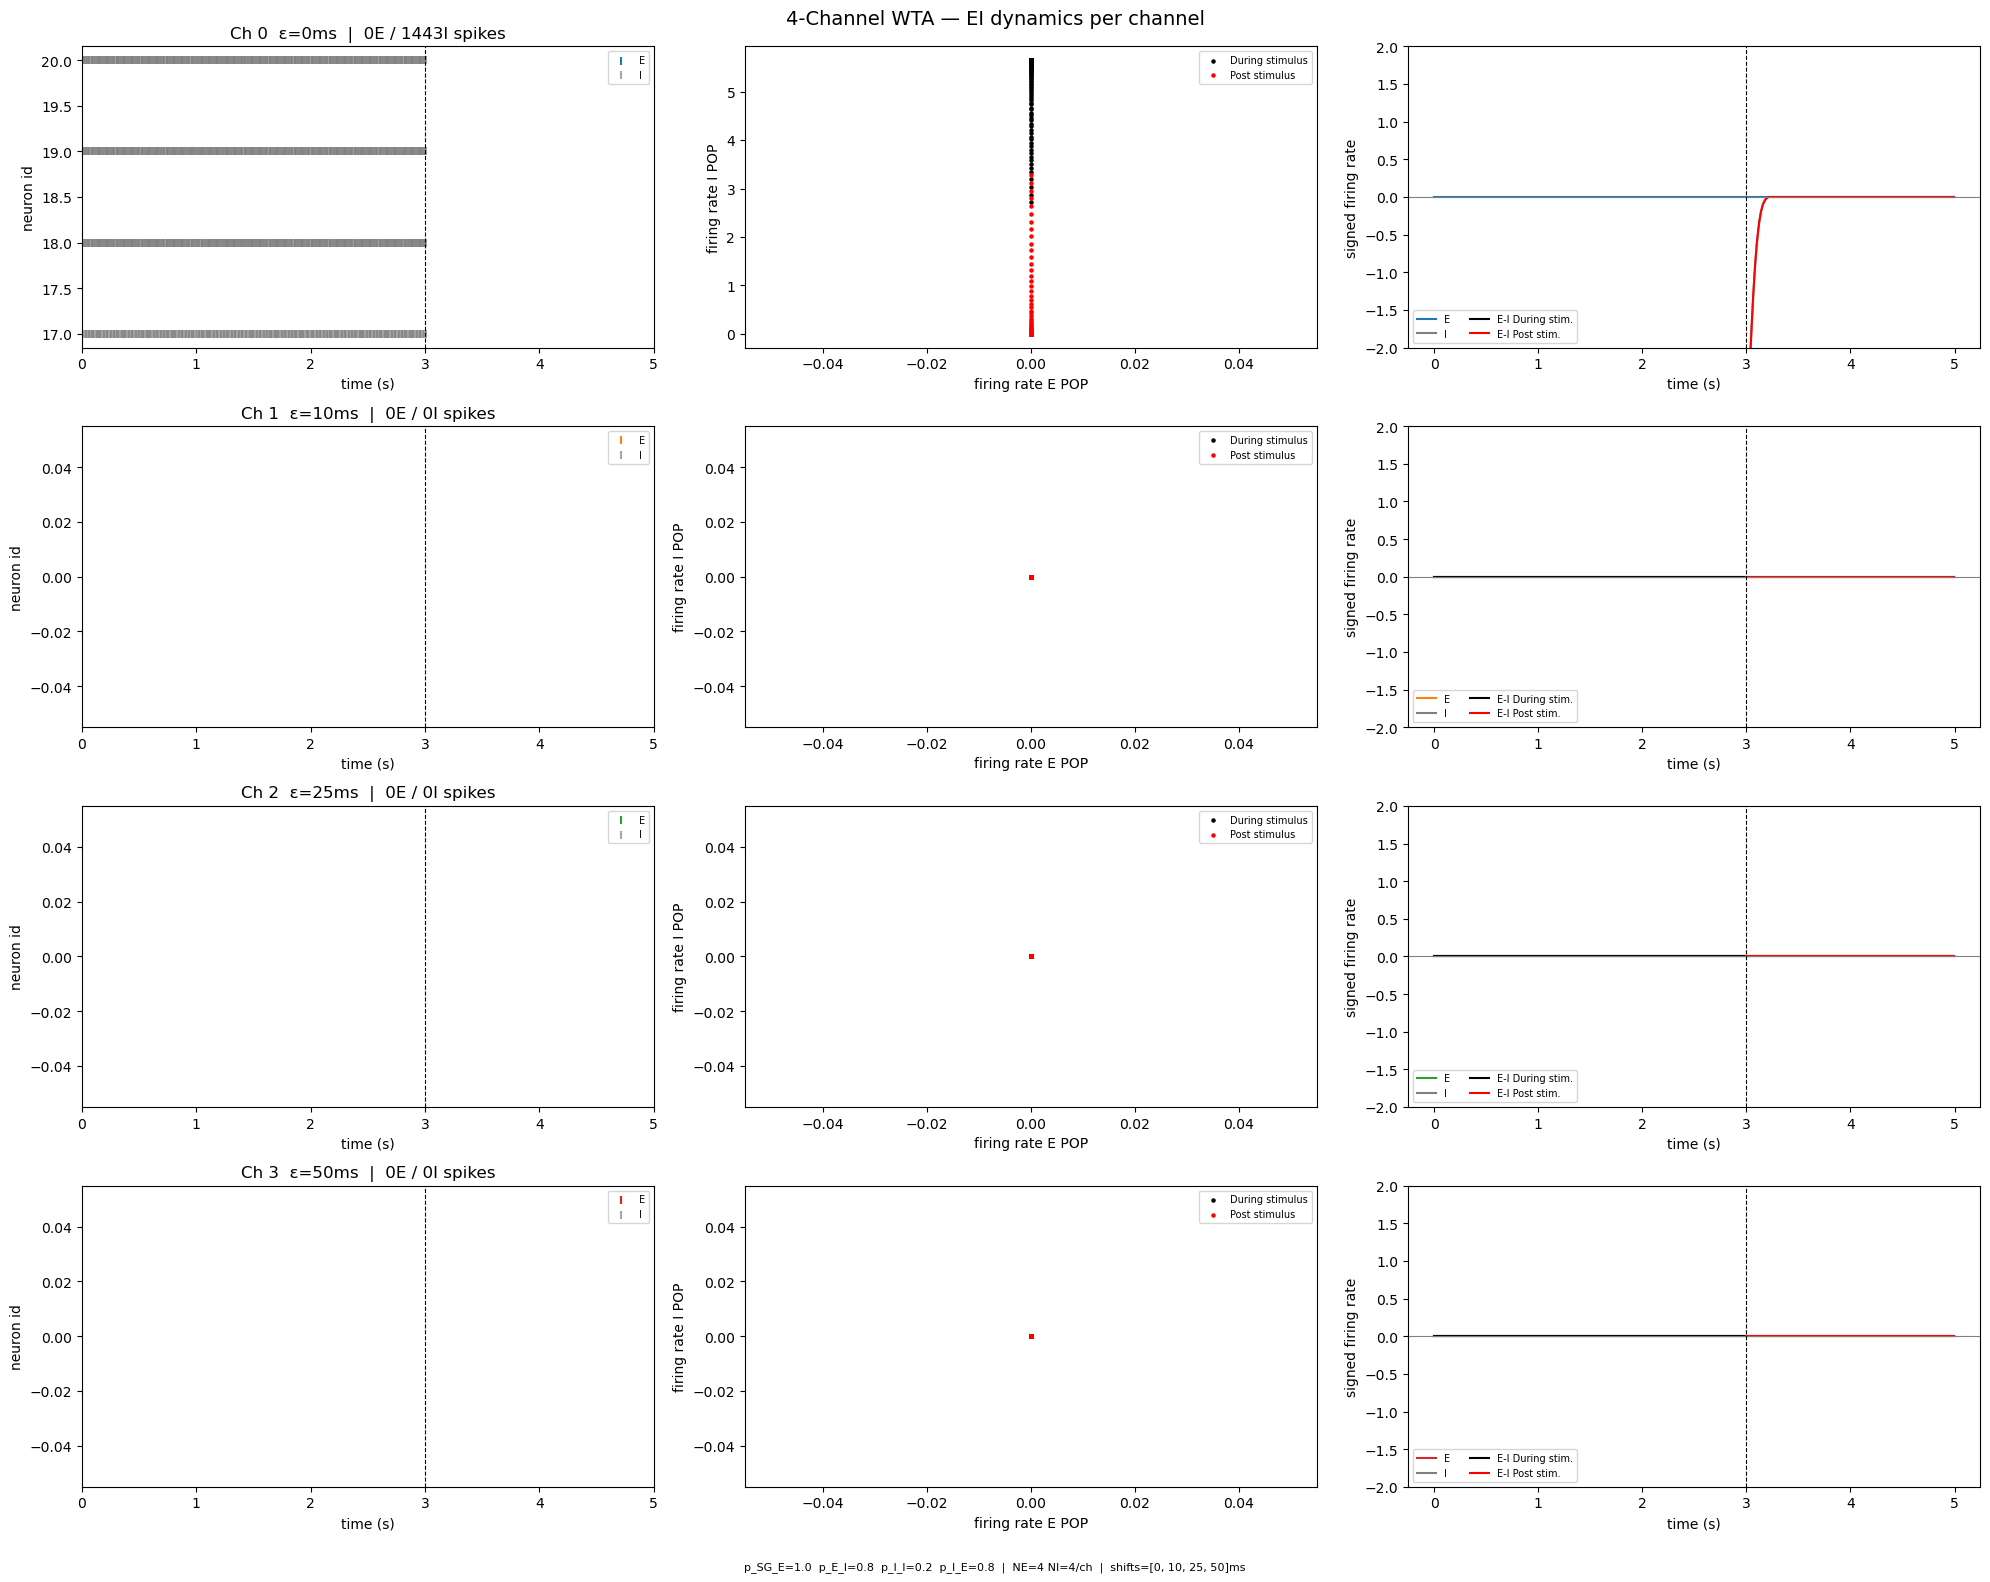

Saved: step3_wta_result.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. PLOT  — 4 rows (channels) × 3 cols (raster | phase | signed rate)
#            exactly like the tutorial EI_balance plot
# ─────────────────────────────────────────────────────────────────────────────

NN   = 256   # neurons per core on DynapseSE1
fs   = 200
D    = D_stim + D_post

# global spike id  (core * NN + neuron_id)  — same trick as tutorial
spike_id = spike_core * NN + spike_nrn

# Gaussian kernel (same as tutorial)
sigma = 0.01
x     = np.arange(int(-0.2 * fs), int(0.2 * fs)) / fs
gauss = np.exp(-x**2 / sigma)

# global ID ranges per channel
#   core 0, E: ch0→1-4, ch1→5-8, ch2→9-12, ch3→13-16
#   core 0, I: ch0→17-20, ch1→21-24, ch2→25-28, ch3→29-32
def g_range(ch):
    e_lo = 0*NN + 1  + ch * NE_CH      # global
    e_hi = e_lo + NE_CH
    i_lo = 0*NN + 17 + ch * NI_CH
    i_hi = i_lo + NI_CH
    return e_lo, e_hi, i_lo, i_hi

COLORS     = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
stim_bins  = int(D_stim * fs)
post_bins  = int(D_post  * fs)
t_stim_ax  = np.arange(stim_bins) / fs
t_post_ax  = np.arange(post_bins) / fs + D_stim
t_all_ax   = np.arange(int(D * fs)) / fs

fig, axes = plt.subplots(N_CH, 3, figsize=(20, 4 * N_CH))
fig.suptitle("4-Channel WTA — EI dynamics per channel", fontsize=14)

for ch in range(N_CH):
    e_lo, e_hi, i_lo, i_hi = g_range(ch)

    mask_E = (spike_id >= e_lo) & (spike_id < e_hi)
    mask_I = (spike_id >= i_lo) & (spike_id < i_hi)

    t_E  = spike_t[mask_E];  id_E = spike_id[mask_E]
    t_I  = spike_t[mask_I];  id_I = spike_id[mask_I]

    # binned population activity
    binPOP = np.zeros((2, int(D * fs)))
    for t in t_E:
        if 0 <= t < D:
            binPOP[0, int(t * fs)] = 1
    for t in t_I:
        if 0 <= t < D:
            binPOP[1, int(t * fs)] = 1

    binPOP[0] = np.convolve(binPOP[0], gauss, 'same')
    binPOP[1] = np.convolve(binPOP[1], gauss, 'same')

    ax1, ax2, ax3 = axes[ch]

    # ── raster ───────────────────────────────────────────────────────────
    ax1.scatter(t_E, id_E, marker='|', s=40, color=COLORS[ch], label='E')
    ax1.scatter(t_I, id_I, marker='|', s=40, color='gray',     label='I', alpha=0.7)
    ax1.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.set_xlim(0, D)
    ax1.set_title(f"Ch {ch}  ε={J_SHIFT_PARAM[ch]}ms  |  {mask_E.sum()}E / {mask_I.sum()}I spikes")
    ax1.legend(fontsize=7)

    # ── phase portrait ───────────────────────────────────────────────────
    ax2.scatter(binPOP[0, :stim_bins] / NE_CH,
                binPOP[1, :stim_bins] / NI_CH,
                c='k', s=5, label='During stimulus')
    ax2.scatter(binPOP[0, stim_bins:] / NE_CH,
                binPOP[1, stim_bins:] / NI_CH,
                c='red', s=5, label='Post stimulus')
    ax2.set_xlabel('firing rate E POP')
    ax2.set_ylabel('firing rate I POP')
    ax2.legend(fontsize=7)

    # ── signed firing rate ───────────────────────────────────────────────
    ax3.plot(t_all_ax,  binPOP[0] / NE_CH, color=COLORS[ch], label='E')
    ax3.plot(t_all_ax, -binPOP[1] / NI_CH, color='gray',     label='I')
    ax3.plot(t_stim_ax,
             binPOP[0, :stim_bins] / NE_CH - binPOP[1, :stim_bins] / NI_CH,
             c='k', label='E-I During stim.')
    ax3.plot(t_post_ax,
             binPOP[0, stim_bins:] / NE_CH - binPOP[1, stim_bins:] / NI_CH,
             c='red', label='E-I Post stim.')
    ax3.axhline(0, color='gray', lw=0.8)
    ax3.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax3.set_xlabel('time (s)')
    ax3.set_ylabel('signed firing rate')
    ax3.set_ylim(-2, 2)
    ax3.legend(loc='lower left', ncol=2, fontsize=7)

plt.figtext(
    0.5, 0.005,
    f"p_SG_E={p_SG_E}  p_E_I={p_E_I}  p_I_I={p_I_I}  p_I_E={p_I_E}  |  "
    f"NE={NE_CH} NI={NI_CH}/ch  |  shifts={J_SHIFT_PARAM}ms",
    ha='center', fontsize=8
)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("keyspot_plots\step3_wta_result.png", dpi=150)
plt.show()
print("Saved: step3_wta_result.png")

Network configuration applied.New configuration applied to DYNAP-SE1!

Recorded 0 events.


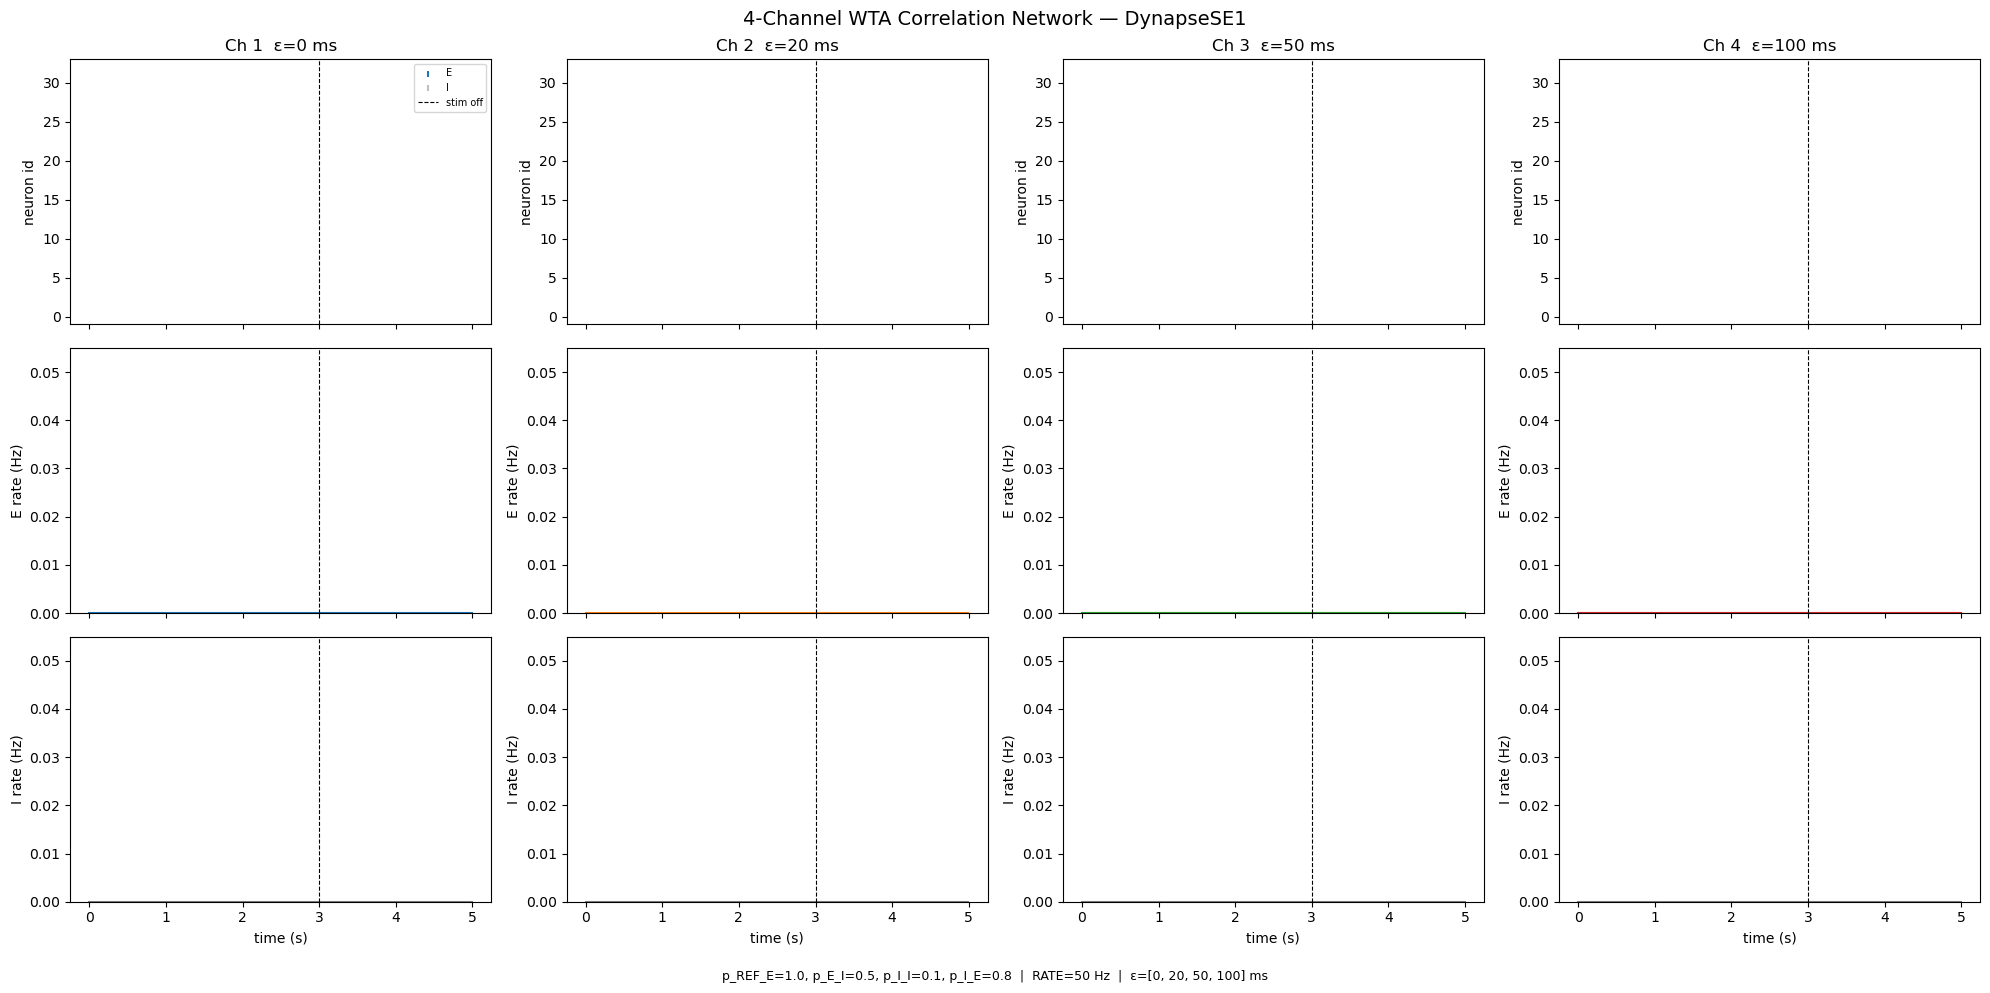

Plot saved to wta_4ch_result.png


In [ ]:
# """
# 4-Channel Winner-Take-All (WTA) Correlation Network on DynapseSE1
# =================================================================
# Architecture (from lecture slide):
#   - 1 reference spike generator
#   - 4 channels, each with 16 E + 16 I neurons
#   - Each channel receives a spike pattern: same frequency 1/T, shifted by ε_k
#   - Reference pattern is the "ground truth" timing
#   - E neurons detect coincidence with reference (NMDA / AMPA)
#   - I neurons enforce competition across channels (GABA_B cross-inhibition = WTA)
#   - Winning channel = most correlated with reference → drives I to silence others

# Chip/Core layout (DynapseSE1 — 4 cores × 256 neurons per chip):
#   CHIP 0
#   ├── CORE 0: Channel 1 E (neurons 0–15),  Channel 1 I (neurons 16–31)
#   ├── CORE 1: Channel 2 E (neurons 0–15),  Channel 2 I (neurons 16–31)
#   ├── CORE 2: Channel 3 E (neurons 0–15),  Channel 3 I (neurons 16–31)
#   └── CORE 3: Channel 4 E (neurons 0–15),  Channel 4 I (neurons 16–31)

#   CHIP 0, CORE 0, neuron 32 → reference spike generator
#     (adjust to a free neuron slot on whichever core/chip you prefer)

# Synapse types used:
#   AMPA  — fast excitation (spikegen → E, E → I within channel)
#   NMDA  — slow/persistent excitation (reference → E coincidence detection)
#   GABA_A — local inhibition (I → I within channel, optional)
#   GABA_B — cross-channel inhibition for WTA (I → E of OTHER channels)
# """



# # Load default parameter group (you can swap this for a custom param_group)


# # ─────────────────────────────────────────────────────────────────────────────
# # 1. NETWORK PARAMETERS
# # ─────────────────────────────────────────────────────────────────────────────

# N_CH  = 4    # number of channels
# NE    = 16   # excitatory neurons per channel
# NI    = 16   # inhibitory neurons per channel
# CHIP  = 0    # all on chip 0

# # Connection probabilities
# p_REF_E  = 1.0   # reference → E (coincidence detection, NMDA)
# p_E_I    = 0.5   # E → I within channel (AMPA)
# p_I_I    = 0.1   # I → I within channel (GABA_A, local suppression)
# p_I_E    = 0.8   # I → E of OTHER channels (GABA_B, WTA cross-inhibition)

# # Stimulus parameters
# RATE_HZ      = 50    # base Poisson rate of each channel pattern (Hz)
# REF_RATE_HZ  = 50    # reference pattern rate
# D_stim       = 3.0   # stimulus duration (s)
# D_post       = 2.0   # post-stimulus recording (s)
# D            = D_stim + D_post

# # Temporal offsets per channel (in ms) — channel k is shifted by epsilon_k
# # Channel 0 is aligned to reference (ε=0), others are increasingly shifted
# J_SHIFT_PARAM = [0, 20, 50, 100]   # [ch0, ch1, ch2, ch3]  — adjust as needed


# # ─────────────────────────────────────────────────────────────────────────────
# # 2. NEURON ID ASSIGNMENT
# # ─────────────────────────────────────────────────────────────────────────────
# # Layout per core:
# #   neuron   0     → RESERVED on DynapseSE1 — do NOT use
# #   neurons  1–16  → E population for this channel
# #   neurons 17–32  → I population for this channel
# # Reference spike generator: chip=0, core=0, neuron=33
# # Channel spikegens: each core, neuron=34

# REF_SPIKEGEN_ID  = (0, 0, 1)          # reference: chip 0, core 0, neuron 33
# CH_SPIKEGEN_NRN  = 34                     # per-channel spikegen slot (same on each core)
# E_START          = 1                      # first E neuron slot (0 is reserved!)
# I_START          = E_START + NE           # first I neuron slot

# ch_spikegens = []    # one Poisson input per channel
# ch_E_neurons = []    # list of 4 × NE Neuron objects
# ch_I_neurons = []    # list of 4 × NI Neuron objects

# for ch in range(N_CH):
#     core = ch  # channel ch lives on core ch
#     # channel spike generator
#     ch_spikegens.append(Neuron(CHIP, core, CH_SPIKEGEN_NRN, True))

#     # E neurons: slots 1–NE  (skip slot 0 — reserved)
#     e_nrns = [Neuron(CHIP, core, E_START + ni) for ni in range(NE)]
#     ch_E_neurons.append(e_nrns)

#     # I neurons: slots NE+1 – NE+NI
#     i_nrns = [Neuron(CHIP, core, I_START + ni) for ni in range(NI)]
#     ch_I_neurons.append(i_nrns)

# ref_spikegen = Neuron(REF_SPIKEGEN_ID[0], REF_SPIKEGEN_ID[1], REF_SPIKEGEN_ID[2], True)


# # ─────────────────────────────────────────────────────────────────────────────
# # 3. NETWORK WIRING
# # ─────────────────────────────────────────────────────────────────────────────

# net_gen = NetworkGenerator()
# net_gen.clear_network()

# for ch in range(N_CH):
#     E = ch_E_neurons[ch]
#     I = ch_I_neurons[ch]

#     # 3a. Reference → E  (NMDA — coincidence detection)
#     for e in E:
#         if p_REF_E > np.random.uniform():
#             net_gen.add_connection(ref_spikegen, e, dyn1.Dynapse1SynType.NMDA)

#     # 3b. Channel spikegen → E  (AMPA — channel-specific drive)
#     for e in E:
#         net_gen.add_connection(ch_spikegens[ch], e, dyn1.Dynapse1SynType.AMPA)

#     # 3c. E → I within channel  (AMPA)
#     for e in E:
#         for i_nrn in I:
#             if p_E_I > np.random.uniform():
#                 net_gen.add_connection(e, i_nrn, dyn1.Dynapse1SynType.AMPA)

#     # 3d. I → I within channel  (GABA_A, local stabilisation)
#     for idx_i, i_nrn in enumerate(I):
#         for idx_j, j_nrn in enumerate(I):
#             if idx_i != idx_j and p_I_I > np.random.uniform():
#                 net_gen.add_connection(i_nrn, j_nrn, dyn1.Dynapse1SynType.GABA_A)

#     # 3e. I → E of ALL OTHER channels  (GABA_B, WTA cross-inhibition)
#     for other_ch in range(N_CH):
#         if other_ch == ch:
#             continue
#         for i_nrn in I:
#             for e in ch_E_neurons[other_ch]:
#                 if p_I_E > np.random.uniform():
#                     net_gen.add_connection(i_nrn, e, dyn1.Dynapse1SynType.GABA_B)

# # Apply network configuration
# new_config = net_gen.make_dynapse1_configuration()
# model.apply_configuration(new_config)
# print("Network configuration applied.")


# # ─────────────────────────────────────────────────────────────────────────────
# # 4. SPIKE PATTERN GENERATION
# # ─────────────────────────────────────────────────────────────────────────────
# # The DynapseSE1 Poisson generator fires at a fixed rate.
# # We use it for the reference and for each channel.
# # The "shift" (epsilon) is implemented by delaying the start of each channel's
# # Poisson generator by epsilon_k milliseconds before recording.
# #
# # For precise control, you can also pre-compute spike times and inject them
# # via the spike injector API — see samna docs for write_spike_train().

# poisson_gen = model.get_poisson_gen()
# poisson_gen.set_chip_id(CHIP)

# # Global IDs for each spikegen (needed by the Poisson generator API)
# ref_global_id   = ut.get_global_id(REF_SPIKEGEN_ID[0], REF_SPIKEGEN_ID[1], REF_SPIKEGEN_ID[2])
# ch_global_ids   = [
#     ut.get_global_id(CHIP, ch, CH_SPIKEGEN_NRN)
#     for ch in range(N_CH)
# ]

# # Set rates
# poisson_gen.write_poisson_rate_hz(ref_global_id, REF_RATE_HZ)
# for ch_id in ch_global_ids:
#     poisson_gen.write_poisson_rate_hz(ch_id, RATE_HZ)


# # ─────────────────────────────────────────────────────────────────────────────
# # 5. RECORDING SETUP
# # ─────────────────────────────────────────────────────────────────────────────

# # All E and I neurons across all channels
# all_monitored = []
# for ch in range(N_CH):
#     all_monitored.extend([(CHIP, ch, E_START + ni) for ni in range(NE)])   # E: slots 1..NE
#     all_monitored.extend([(CHIP, ch, I_START + ni) for ni in range(NI)])   # I: slots NE+1..NE+NI

# graph, filter_node, sink_node = ut.create_neuron_select_graph(model, all_monitored)


# # ─────────────────────────────────────────────────────────────────────────────
# # 6. RUN EXPERIMENT
# # ─────────────────────────────────────────────────────────────────────────────



# # from utils function to send channels to dynapse via sp
# ### def set_fpga_spike_gen(fpga_spike_gen, spike_times, indices, target_chips, isi_base, repeat_mode=False):



# set_params(model, param_group=param_group)

# graph.start()
# sink_node.get_events()   # flush buffer
# api.reset_timestamp()

# # Start reference
# poisson_gen.write_poisson_rate_hz(ref_global_id, REF_RATE_HZ)

# # Start each channel, staggered by epsilon_k
# for ch in range(N_CH):
#     eps_s = J_SHIFT_PARAM[ch] * 1e-3
#     time.sleep(eps_s)
#     poisson_gen.write_poisson_rate_hz(ch_global_ids[ch], RATE_HZ)

# # Wait for remaining stimulus time (approximate — account for stagger overhead)
# time.sleep(D_stim)

# # Stop all spikegens
# poisson_gen.write_poisson_rate_hz(ref_global_id, 0)
# for ch_id in ch_global_ids:
#     poisson_gen.write_poisson_rate_hz(ch_id, 0)

# time.sleep(D_post)
# graph.stop()
# events = sink_node.get_events()
# print(f"Recorded {len(events)} events.")


# # ─────────────────────────────────────────────────────────────────────────────
# # 7. SPIKE SORTING
# # ─────────────────────────────────────────────────────────────────────────────
# # Each event carries: chip_id, core_id, neuron_id, timestamp (µs)
# # We split into per-channel, per-population arrays.

# NN_CORE = 256   # neurons per core on DynapseSE1

# spike_times   = []   # parallel arrays
# spike_core    = []
# spike_nrn     = []

# for evt in events:
#     spike_times.append(evt.timestamp * 1e-6)    # convert µs → s
#     spike_core.append(evt.core_id)
#     spike_nrn.append(evt.neuron_id)

# spike_times = np.array(spike_times)
# spike_core  = np.array(spike_core,  dtype=int)
# spike_nrn   = np.array(spike_nrn,   dtype=int)

# def get_ch_spikes(ch, pop='E'):
#     """Return (times, neuron_ids) for channel ch, population 'E' or 'I'."""
#     mask_core = spike_core == ch
#     if pop == 'E':
#         mask_nrn = (spike_nrn >= E_START) & (spike_nrn < E_START + NE)
#     else:
#         mask_nrn = (spike_nrn >= I_START) & (spike_nrn < I_START + NI)
#     mask = mask_core & mask_nrn
#     return spike_times[mask], spike_nrn[mask]




# # ─────────────────────────────────────────────────────────────────────────────
# # 8. FIRING RATE ESTIMATION (Gaussian kernel)
# # ─────────────────────────────────────────────────────────────────────────────

# fs    = 200          # sampling rate for population rate estimate (Hz)
# sigma = 0.05         # kernel width (s)
# bins  = int(D * fs)
# t_ax  = np.arange(bins) / fs

# x_k   = np.arange(int(-0.5*fs), int(0.5*fs)) / fs
# gauss = np.exp(-x_k**2 / (2 * sigma**2))
# gauss /= gauss.sum()

# def population_rate(times, nrn_ids, n_neurons, fs=fs, bins=bins):
#     """Estimate smoothed population firing rate (Hz) from spike times.
#     nrn_ids is accepted but unused here (kept for clean *-unpacking from get_ch_spikes)."""
#     binary = np.zeros(bins)
#     idx    = (times * fs).astype(int)
#     idx    = idx[(idx >= 0) & (idx < bins)]
#     binary[idx] = 1
#     rate = np.convolve(binary, gauss, 'same') * fs / n_neurons
#     return rate

# ch_E_rate = [population_rate(*get_ch_spikes(ch, 'E'), n_neurons=NE) for ch in range(N_CH)]
# ch_I_rate = [population_rate(*get_ch_spikes(ch, 'I'), n_neurons=NI) for ch in range(N_CH)]


# # ─────────────────────────────────────────────────────────────────────────────
# # 9. VISUALISATION
# # ─────────────────────────────────────────────────────────────────────────────

# COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# fig, axes = plt.subplots(3, N_CH, figsize=(5*N_CH, 10), sharex=True)
# fig.suptitle("4-Channel WTA Correlation Network — DynapseSE1", fontsize=14)

# for ch in range(N_CH):
#     t_E, n_E = get_ch_spikes(ch, 'E')
#     t_I, n_I = get_ch_spikes(ch, 'I')

#     # Row 0: raster
#     ax = axes[0, ch]
#     ax.scatter(t_E, n_E,      color=COLORS[ch], marker='|', s=20, label='E')
#     ax.scatter(t_I, n_I + NE, color='gray',     marker='|', s=20, alpha=0.5, label='I')
#     ax.axvline(D_stim, color='k', lw=0.8, ls='--', label='stim off')
#     ax.set_title(f"Ch {ch+1}  ε={J_SHIFT_PARAM[ch]} ms")
#     ax.set_ylabel("neuron id")
#     ax.set_ylim(-1, NE + NI + 1)
#     if ch == 0:
#         ax.legend(fontsize=7, loc='upper right')

#     # Row 1: E population rate
#     ax = axes[1, ch]
#     ax.plot(t_ax, ch_E_rate[ch], color=COLORS[ch])
#     ax.axvline(D_stim, color='k', lw=0.8, ls='--')
#     ax.set_ylabel("E rate (Hz)")
#     ax.set_ylim(bottom=0)

#     # Row 2: I population rate
#     ax = axes[2, ch]
#     ax.plot(t_ax, ch_I_rate[ch], color='gray')
#     ax.axvline(D_stim, color='k', lw=0.8, ls='--')
#     ax.set_xlabel("time (s)")
#     ax.set_ylabel("I rate (Hz)")
#     ax.set_ylim(bottom=0)

# plt.figtext(
#     0.5, 0.01,
#     f"p_REF_E={p_REF_E}, p_E_I={p_E_I}, p_I_I={p_I_I}, p_I_E={p_I_E}  |  "
#     f"RATE={RATE_HZ} Hz  |  ε={J_SHIFT_PARAM} ms",
#     ha='center', fontsize=9
# )
# plt.tight_layout(rect=[0, 0.03, 1, 1])
# plt.savefig("wta_4ch_result.png", dpi=150)
# plt.show()
# print("Plot saved to wta_4ch_result.png")

In [10]:
# print AMPA weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

Linear: 752941184.0
Coarse: 7
Fine: 80


In [8]:
param_group = config1.chips[0].cores[0].parameter_group 

In [9]:
# set AMPA (fast excitatory) weight 

param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value = 160
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 4


In [10]:
# print AMPA (fast excitatory) weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

Linear: 3137255.0
Coarse: 4
Fine: 160


In [11]:
# set NMDA (slow excitatory) weight

param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 180
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 4

# param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 0
# param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 0

In [12]:
# print NMDA (slow excitatory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))

Linear: 3529412.0
Coarse: 4
Fine: 180


In [13]:
# set GABA B (slow inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value = 150
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 4

In [14]:
# print GABA B (slow inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))

Linear: 2941177.0
Coarse: 4
Fine: 150


In [15]:
# set GABA A (fast inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value = 200
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 4

In [16]:
# print GABA A (fast inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))

Linear: 3921569.0
Coarse: 4
Fine: 200


In [29]:
# set NMDA (slow exc) tau 
# remember the higher the tau param, the higher the leak, the faster the decay

param_group.param_map['NPDPIE_TAU_S_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

In [18]:
# print NMDA (slow exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))

Linear: 137647.0
Coarse: 4
Fine: 7


In [30]:
# # set AMPA (fast exc) tau 

param_group.param_map['NPDPIE_TAU_F_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

In [20]:
# print AMPA (fast exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))

Linear: 99412.0
Coarse: 4
Fine: 5


In [34]:
param_group.param_map["NPDPII_TAU_F_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_F_P"].fine_value = 8

param_group.param_map["NPDPII_TAU_S_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_S_P"].fine_value = 8

In [22]:
#config1 = model.get_configuration() 

### checl range of params 
param = config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P']
print(param)
dir(param)
type(param.coarse_value)
print(param.coarse_value)

dynapse1::Dynapse1Parameter param_name=NPDPIE_TAU_S_P, coarse_value=4, fine_value=7, type=P.
4


225 NMDA synapses
New configuration applied to DYNAP-SE1!
monitored neurons: [(0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 0, 6), (0, 0, 7), (0, 0, 8), (0, 0, 9), (0, 0, 10), (0, 0, 11), (0, 0, 12), (0, 0, 13), (0, 0, 14), (0, 0, 15), (0, 0, 16), (0, 0, 17), (0, 0, 18), (0, 0, 19), (0, 0, 20), (0, 0, 21), (0, 0, 22), (0, 0, 23), (0, 0, 24), (0, 0, 25), (0, 0, 26), (0, 0, 27), (0, 0, 28), (0, 0, 29), (0, 0, 30), (0, 0, 31), (0, 0, 32), (0, 0, 33), (0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 38), (0, 0, 39), (0, 0, 41), (0, 0, 42), (0, 0, 43), (0, 0, 44), (0, 0, 45), (0, 0, 46), (0, 0, 47), (0, 0, 48), (0, 0, 49), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 54), (0, 0, 55), (0, 0, 56), (0, 0, 57), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 62), (0, 0, 63), (0, 0, 64), (0, 0, 65), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 70), (0, 0, 71), (0, 0, 72), (0, 0, 73), (0, 0, 74), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 78), (0, 0, 

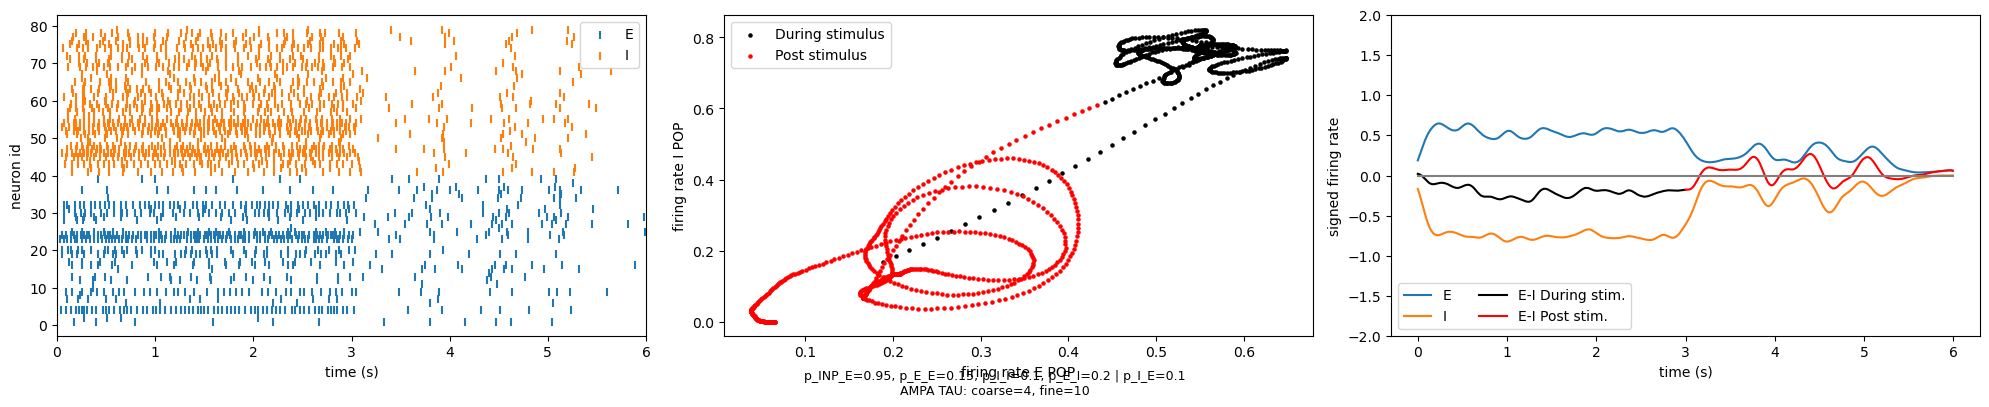

In [ ]:
#import importlib # Module to dynamically reload modules
#importlib.reload(params) # Reloads the params module to ensure any changes are recognized

###what does this actually do ? 
model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

p_INP_E = 0.95       # Probability of connections from spike generator to excitatory population
p_E_E   = 0.15        # Probability of connections among excitatory neurons
p_I_I   = 0.1           # Probability of connections among inhibitory neurons
p_E_I   = 0.2      # Probability of connections from excitatory to inhibitory
p_I_E   = 0.1          # Probability of connections from inhibitory to excitatory

# p_INP_E = .7            # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.1          # Probability of connections among excitatory neurons
# p_I_I   = 0.5             # Probability of connections among inhibitory neurons
# p_E_I   = 0.2           # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.5 

#### Given 

#model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

# p_INP_E = 1             # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.8             # Probability of connections among excitatory neurons
# p_I_I   = 0.0             # Probability of connections among inhibitory neurons
# p_E_I   = 0.5             # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.0             # Probability of connections from inhibitory to excitatory

# We use CHIP 0 in this exercise 
    # remember, there are 4 chips per every blue box. There are 4 cores per every chip. There are 256 neurons per every core.
    
# We are using a SPIKEGEN located  in CORE 1. POPULATION E is in CORE 0. POPULATION I is in CORE 0.
    # when you set up your own EI balanced networks in the future, we advise that you keep the POPULATION E and POPULATION I in different cores to more easily control the parameters

# Create a NetworkGenerator object to build the network configuration:
net_gen = NetworkGenerator()
net_gen.clear_network() # Clear any existing network structure

# We will create a spike generator in chip=0, core=1, neuron=1

spikegen_ids = [(0, 1, 1)]
spikegens = []
for spikegen_id in spikegen_ids:
    spikegens.append(Neuron(spikegen_id[0],spikegen_id[1],spikegen_id[2],True))
## YOYO accumulkates the spikes in given frequency and precise timing sending to the location of spike:ids @ the chip 




# Define the size of the excitatory population and create their neuron IDs:
NE    = 40
E_ids = [(0,0,ni) for ni in range(1,NE)]
neurons_E = []
for nid in E_ids:
    neurons_E.append(Neuron(nid[0],nid[1],nid[2]))


# Define the size of the inhibitory population and create their neuron IDs
NI    = 40
I_ids = [(0,0,ni+NE) for ni in range(1,NI)]
neurons_I = []
for nid in I_ids:
    neurons_I.append(Neuron(nid[0],nid[1],nid[2]))


# connect SPIKEGEN to POPULATION E:
for i in range(int(NE*p_INP_E)-1):
    # Here, we connect from spikegens[0] to neurons_E[i]
    # using the AMPA synapse type
    net_gen.add_connection(spikegens[0], neurons_E[i], dyn1.Dynapse1SynType.AMPA)

# connect POPULATION E to POPULATION E
    # (Connect excitatory neurons among themselves (E to E) with probability p_E_E)
counter=0
for i in range(NE-1):
    for j in range(NE-1):
        if(i!=j and p_E_E > np.random.uniform()):
            counter+=1
            # Use NMDA synapse type for these connections. So you can tune the parameters of the NMDA and AMPA synapses separately
            net_gen.add_connection(neurons_E[i], neurons_E[j], dyn1.Dynapse1SynType.NMDA)
print(str(counter)+" NMDA synapses")
            
# connect POPULATION E to POPULATION I
for i in range(NE-1):
    for j in range(NI-1):
        if(p_E_I > np.random.uniform()):
            net_gen.add_connection(neurons_E[i], neurons_I[j], dyn1.Dynapse1SynType.AMPA)


# connect POPULATION I to POPULATION I 
for i in range(NI-1):
    for j in range(NI-1):
        if(i!=j and p_I_I > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_I[j], dyn1.Dynapse1SynType.GABA_A)


# connect POPULATION I to POPULATION E
for i in range(NI-1):
    for j in range(NE-1):
        if(p_I_E > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_E[j], dyn1.Dynapse1SynType.GABA_B)

# make a dynapse1config using the network
new_config = net_gen.make_dynapse1_configuration()

# apply the configuration
model.apply_configuration(new_config)


for rate in [50]:
    D_stim = 3 # stimulus duration (s)
    D_post_stim = 3 # post stimulus duration (s)
    D = D_stim + D_post_stim
    global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
    poisson_gen = model.get_poisson_gen()
    poisson_gen.set_chip_id(0)
    poisson_gen.write_poisson_rate_hz(global_poisson_gen_ids[0], rate)
    
    # set parameters
### turned of 
    #set_params(model)#, param_group = param_group) # note here: set_params(model) will revert the params back to the standard params
### newly setted for changing behavior
    set_params(model, param_group = param_group)
    # if you want to use new parameters that you set via this script, you need to use set_params(model, param_group = param_group)
    
    
    # how to get events of selected neurons
    monitored_neurons = E_ids + I_ids
    graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)

### create graphs have to be stopped____________________________________________
    graph.start()

    # start the poisson gen
    poisson_gen.start()

    # select the neurons to monitor
    print("monitored neurons:", monitored_neurons)
    filter_node.set_neurons(monitored_neurons)

    # clear the buffer
    sink_node.get_events()

    api.reset_timestamp()
    time.sleep(D_stim)

    poisson_gen.stop()
    time.sleep(D_post_stim)
    graph.stop()
    events = sink_node.get_events()
    
### create graphs have to be stopped____________________________________________

    # process the events
    print(len(events),"events.")

    NN = 256 # neurons in 1 core
    spike_id = []
    spike_t  = []
    for evt in events:
        spike_id.append(evt.core_id*NN + evt.neuron_id)
        spike_t.append(evt.timestamp*1e-6)
    spike_id = np.array(spike_id)
    spike_t  = np.array(spike_t) 

    # E mean firing rate
    fs = 200
    binPOP = np.zeros((2,int(D*fs)))
    for i in range(len(events)):
        if(spike_t[i]<D):
            binPOP[spike_id[i]//NE,int(spike_t[i]*fs)]=1

    sigma = 0.01
    x = np.arange(int(-0.2*fs),int(0.2*fs))/fs
    gauss = np.exp(-x**2/sigma)

    binPOP[0] = np.convolve(binPOP[0],gauss,'same')
    binPOP[1] = np.convolve(binPOP[1],gauss,'same')

    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))

    ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label='E')
    ax1.scatter(spike_t[spike_id>(NE)],spike_id[spike_id>(NE)],marker='|',label='I')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.legend()
    ax1.set_xlim(0,D)


    ax2.scatter(binPOP[0,:int(D_stim*fs)]/NE,binPOP[1,:int(D_stim*fs)]/NI,c='k',s=5,label='During stimulus')
    ax2.scatter(binPOP[0,int(D_stim*fs):]/NE,binPOP[1,int(D_stim*fs):]/NI,c='red',s=5,label='Post stimulus')
    ax2.set_ylabel('firing rate I POP')
    ax2.set_xlabel('firing rate E POP')
    ax2.legend()

    ax3.plot(np.arange(int(D*fs))/fs,binPOP[0]/NE,label='E')
    ax3.plot(np.arange(int(D*fs))/fs,-binPOP[1]/NI,label='I')
    ax3.plot(np.arange(int(D_stim*fs))/fs,binPOP[0,:int(D_stim*fs)]/NE-binPOP[1,:int(D_stim*fs)]/NI,c='k',label='E-I During stim.')
    ax3.plot(np.arange(int(D_post_stim*fs))/fs+int(D_stim*fs)/fs,binPOP[0,int(D_stim*fs):]/NE-binPOP[1,int(D_stim*fs):]/NI,c='red',label='E-I Post stim.')
    ax3.plot([0,D],[0,0],'gray')
    ax3.set_ylabel('signed firing rate')
    ax3.set_xlabel('time (s)')
    ax3.legend(loc='lower left', ncol=2)
    ax3.set_ylim(-2,2)

###write param to pic

    param = param_group.param_map['NPDPIE_TAU_F_P']

    plt.subplots_adjust(bottom=0.1)
    plt.figtext(0.5, 0.001, f"p_INP_E={p_INP_E}, p_E_E={p_E_E}, p_I_I={p_I_I}, p_E_I={p_E_I} | p_I_E={p_I_E}\n"     f"AMPA TAU: coarse={param.coarse_value}, fine={param.fine_value}",ha="center", fontsize=9)

    plt.tight_layout()
    #plt.savefig('EI.png')
    #plt.savefig(f"./plots/NMDA_syn_{counter}_{p_INP_E}_plt.png")
    plt.show()

Can you achieve something similar as the below figure?

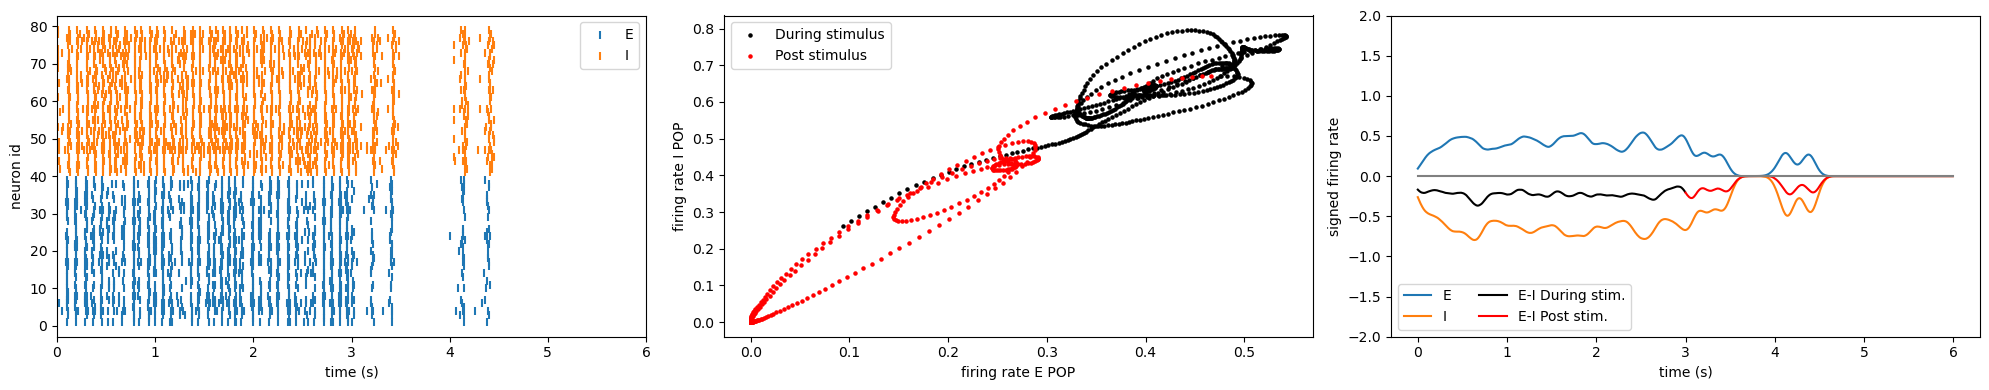

In [24]:
Image("../lab5/EI_balance.png")